# MLP Regressor — Forecast de Consumo Eléctrico

---

**Autor:** Borja Mora Méndez  
**Contacto:** borja.mora.mendez@gmail.com  
**LinkedIn:** [linkedin.com/in/borjamoramendez](https://linkedin.com/in/borjamoramendez)  
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)  
**Categoría:** Machine Learning · Redes Neuronales · MLP · Regresión  
**Dataset:** `electricidad.xlsx` · 719 registros horarios

---

### Objetivo

Construir un modelo **MLP Regressor** capaz de predecir el consumo eléctrico horario y comprobar si una red neuronal aporta valor frente a modelos más sencillos como **Regresión Lineal** y **Random Forest**.

### Contexto de negocio

Una empresa de distribución eléctrica necesita anticipar el consumo para optimizar la compra de energía en el mercado mayorista. Una mala previsión puede generar costes por desviaciones entre el consumo previsto y el real.


## 1️. Setup: librerías y configuración visual

In [1]:
# Librerías base
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Preprocesamiento y modelado
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Modelos
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Métricas
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

# Estilo general
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

# Estilo visual -- sistema de color validado (consejo UX/UI Data)
BACKGROUND    = "#fbfbfb"
PURPLE        = "#7a7bff"
PURPLE_LIGHT  = "#9b9cff"
POSITIVE      = "#6b8158"
NEGATIVE      = "#c34031"
NEUTRAL_BAR   = "#d9d9d9"
NEUTRAL_LINE  = "#8f8c9e"
CONTEXT_LINES = [NEUTRAL_LINE, "#a89a8a", "#7d94a8"]
INK           = "#111111"
MUTED         = "#707070"

DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "borja_diverging", ["#c34031", "#e0a89f", "#f0ede8", "#b7c2a9", "#6b8158"]
)

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 100,
    "figure.facecolor": BACKGROUND,
    "axes.facecolor": BACKGROUND,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": MUTED,
    "axes.labelcolor": INK,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlecolor": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "font.family": "sans-serif",
    "font.size": 10,
    "grid.color": "#f0f0f0",
    "grid.linewidth": 0.5,
})

## 2. Carga de datos

In [2]:
data = pd.read_excel(
    "electricidad.xlsx",
    sheet_name="consumo_electrico"
)

data.columns = ["fecha", "consumo"]
data["fecha"] = pd.to_datetime(data["fecha"])

data = (
    data
    .sort_values("fecha")
    .reset_index(drop=True)
)

print(f"Registros: {data.shape[0]} | Columnas: {data.shape[1]}")
data.head()


Registros: 719 | Columnas: 2


,fecha,consumo
0,2025-01-01 00:00:00,55.467458
1,2025-01-01 01:00:00,56.468145
2,2025-01-01 02:00:00,58.643767
3,2025-01-01 03:00:00,62.734831
4,2025-01-01 04:00:00,65.757901


## 3. EDA: Análisis Exploratorio de Datos

In [3]:
# Estadísticos descriptivos
data.describe().round(2)


,fecha,consumo
count,719,719.00
mean,2025-01-15 23:00:00,54.95
min,2025-01-01 00:00:00,38.36
25%,2025-01-08 11:30:00,45.03
50%,2025-01-15 23:00:00,53.26
75%,2025-01-23 10:30:00,62.74
max,2025-01-30 22:00:00,81.37
std,NaN,11.45


In [4]:
# Comprobar tipos, nulos y valores únicos

print("TIPOS DE DATOS Y VALORES NULOS")
print("─" * 70)

info = pd.DataFrame({
    "Tipo": data.dtypes,
    "Nulos": data.isnull().sum(),
    "% Nulos": (data.isnull().sum() / len(data) * 100).round(2),
    "Únicos": data.nunique()
})

info


TIPOS DE DATOS Y VALORES NULOS
──────────────────────────────────────────────────────────────────────


,Tipo,Nulos,% Nulos,Únicos
fecha,datetime64[ns],0,0.0,719
consumo,float64,0,0.0,719


### Exploración de la variable objetivo: Consumo

El consumo eléctrico es una variable continua. Antes de modelar, interesa comprobar su distribución y detectar si existen valores extremos.


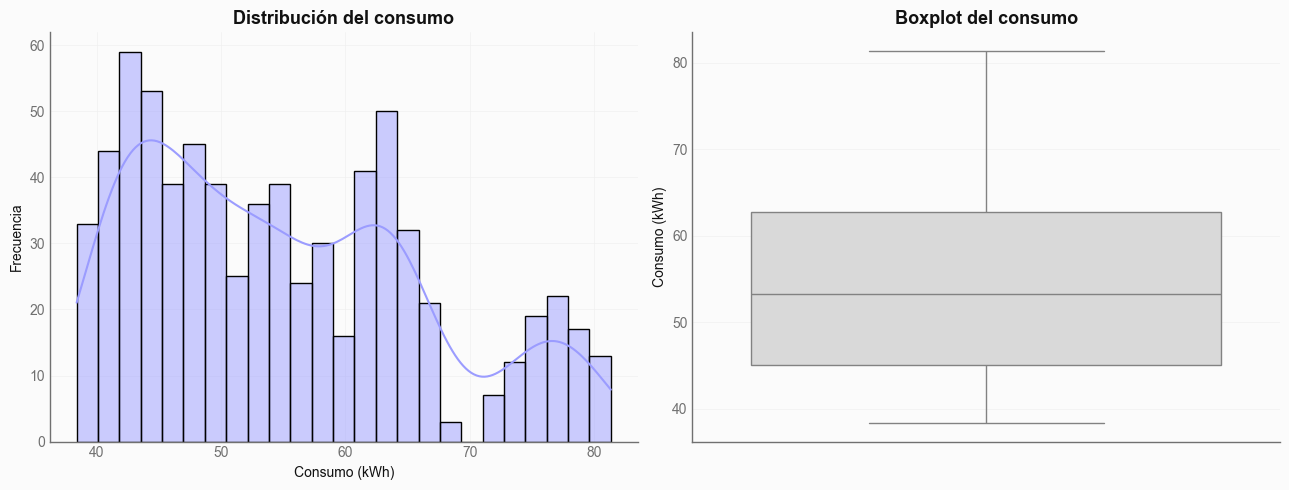

In [5]:
# Distribución del consumo

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(
    data["consumo"],
    bins=25,
    kde=True,
    color=PURPLE_LIGHT,
    ax=axes[0]
)

axes[0].set_title("Distribución del consumo")
axes[0].set_xlabel("Consumo (kWh)")
axes[0].set_ylabel("Frecuencia")

sns.boxplot(
    y=data["consumo"],
    color=NEUTRAL_BAR,
    ax=axes[1]
)

axes[1].set_title("Boxplot del consumo")
axes[1].set_ylabel("Consumo (kWh)")

plt.tight_layout()
plt.show()


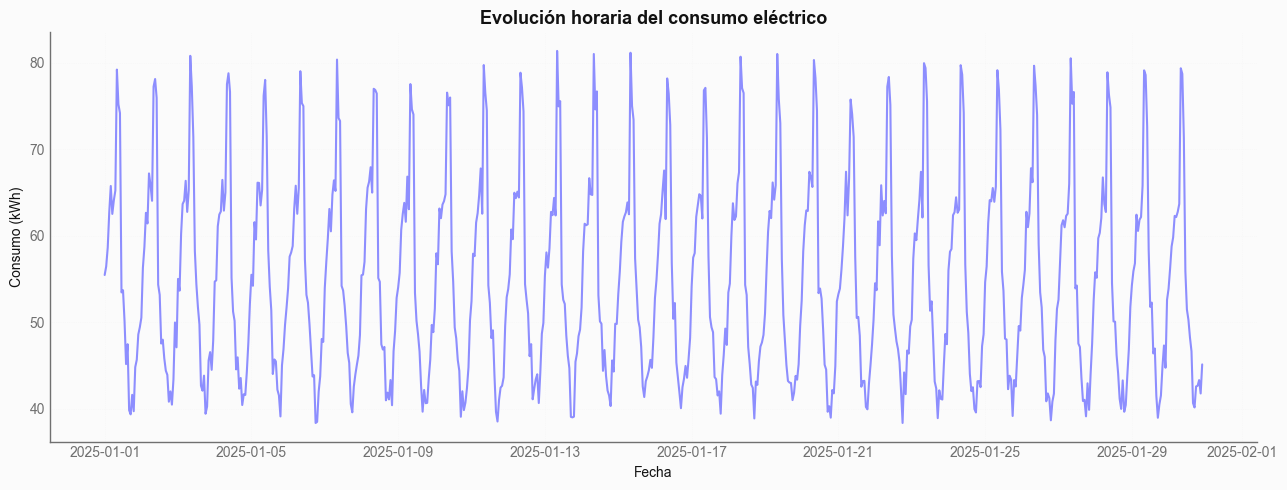

In [6]:
# Evolución temporal del consumo

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(
    data["fecha"],
    data["consumo"],
    color=PURPLE,
    linewidth=1.5,
    alpha=0.85
)

ax.set_title("Evolución horaria del consumo eléctrico")
ax.set_xlabel("Fecha")
ax.set_ylabel("Consumo (kWh)")
ax.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()


### Feature engineering temporal

El consumo tiene una estructura horaria. Para que el modelo pueda aprovecharla se crean variables de calendario y variables cíclicas.

Además, se incorporan dos retardos:

- `consumo_lag1`: consumo de la hora anterior.
- `consumo_lag24`: consumo de la misma hora del día anterior.

Estas variables permiten introducir **memoria temporal** en un modelo que, por sí mismo, no es un modelo de series temporales.


In [7]:
# Crear variables temporales

df = data.copy()

df["hora"] = df["fecha"].dt.hour
df["dia_semana"] = df["fecha"].dt.dayofweek
df["es_fin_semana"] = (df["dia_semana"] >= 5).astype(int)

# Codificación cíclica de la hora
df["hora_sin"] = np.sin(2 * np.pi * df["hora"] / 24)
df["hora_cos"] = np.cos(2 * np.pi * df["hora"] / 24)

# Variables lag
df["consumo_lag1"] = df["consumo"].shift(1)
df["consumo_lag24"] = df["consumo"].shift(24)

df = df.dropna().reset_index(drop=True)

print(f"Registros después del feature engineering: {df.shape[0]}")
df.head(3)


Registros después del feature engineering: 695


,fecha,consumo,hora,dia_semana,es_fin_semana,hora_sin,hora_cos,consumo_lag1,consumo_lag24
0,2025-01-02 00:00:00,50.530399,0,3,0,0.000000,1.000000,49.430375,55.467458
1,2025-01-02 01:00:00,56.281866,1,3,0,0.258819,0.965926,50.530399,56.468145
2,2025-01-02 02:00:00,58.724591,2,3,0,0.500000,0.866025,56.281866,58.643767


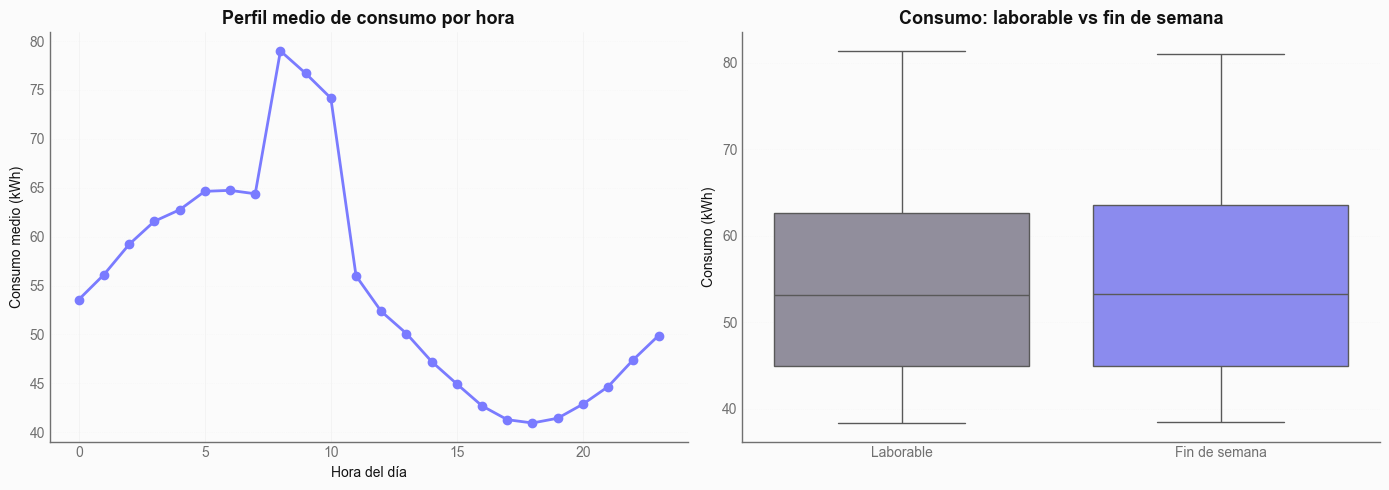

In [8]:
# Patrón diario y efecto del fin de semana

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

perfil = df.groupby("hora")["consumo"].mean()

axes[0].plot(
    perfil.index,
    perfil.values,
    "o-",
    color=PURPLE,
    linewidth=2
)

axes[0].set_title("Perfil medio de consumo por hora")
axes[0].set_xlabel("Hora del día")
axes[0].set_ylabel("Consumo medio (kWh)")
axes[0].grid(axis="y", linestyle=":", alpha=0.5)

sns.boxplot(
    data=df,
    x="es_fin_semana",
    y="consumo",
    hue="es_fin_semana",
    palette={0: CONTEXT_LINES[0], 1: PURPLE},
    legend=False,
    ax=axes[1]
)

axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Laborable", "Fin de semana"])
axes[1].set_title("Consumo: laborable vs fin de semana")
axes[1].set_xlabel("")
axes[1].set_ylabel("Consumo (kWh)")
axes[1].grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()


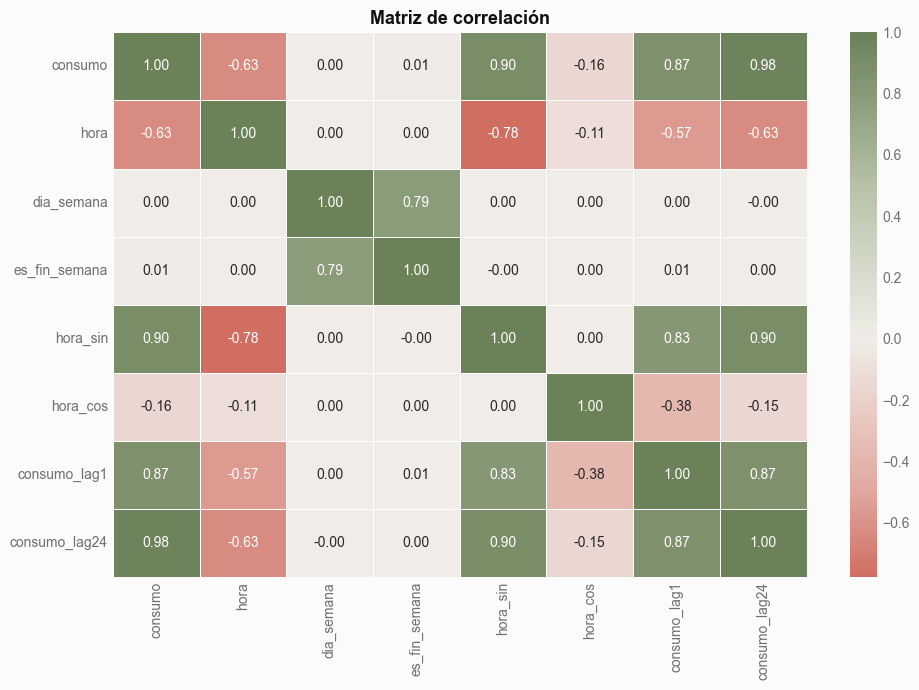

In [9]:
# Matriz de correlación

cols_num = [
    "consumo",
    "hora",
    "dia_semana",
    "es_fin_semana",
    "hora_sin",
    "hora_cos",
    "consumo_lag1",
    "consumo_lag24"
]

corr = df[cols_num].corr()

fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap=DIVERGING_CMAP,
    center=0,
    linewidths=0.5,
    ax=ax
)

ax.set_title("Matriz de correlación")
plt.tight_layout()
plt.show()


### Lectura del EDA

Los retardos `consumo_lag1` y `consumo_lag24` permiten incorporar información reciente y el patrón diario del consumo. La hora y su codificación cíclica aportan la estructura intradía, mientras que el indicador de fin de semana permite diferenciar el comportamiento entre días laborables y fines de semana.


## 4. Train / Test Split

Al tratarse de datos horarios, **no se mezclan las observaciones**. El 80% inicial se utiliza para entrenamiento y el 20% final para test.

Esto reproduce mejor un escenario real: el modelo aprende del pasado y predice horas posteriores.


In [10]:
features = [
    "hora",
    "dia_semana",
    "es_fin_semana",
    "hora_sin",
    "hora_cos",
    "consumo_lag1",
    "consumo_lag24"
]

X = df[features]
y = df["consumo"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    shuffle=False
)

# El escalado se ajusta únicamente con Train
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f"Train: {X_train_sc.shape[0]} | Test: {X_test_sc.shape[0]}")


Train: 556 | Test: 139


## 5. Modelo principal — MLP Regressor

La red neuronal utiliza tres capas ocultas:

**128 → 64 → 32 neuronas**

- Activación: ReLU
- Optimizador: Adam
- `early_stopping=True`
- Máximo: 500 iteraciones

El escalado es especialmente importante en una red neuronal para evitar que las variables con mayor escala dominen el aprendizaje.


In [11]:
# MLP Regressor

mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.15
)

mlp.fit(X_train_sc, y_train)

y_pred_mlp = mlp.predict(X_test_sc)

mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
r2_mlp = r2_score(y_test, y_pred_mlp)

print("MLP Regressor:")
print(f"  MAE:  {mae_mlp:.2f} kWh")
print(f"  RMSE: {rmse_mlp:.2f} kWh")
print(f"  R²:   {r2_mlp:.3f}")


MLP Regressor:
  MAE:  1.92 kWh
  RMSE: 2.43 kWh
  R²:   0.957


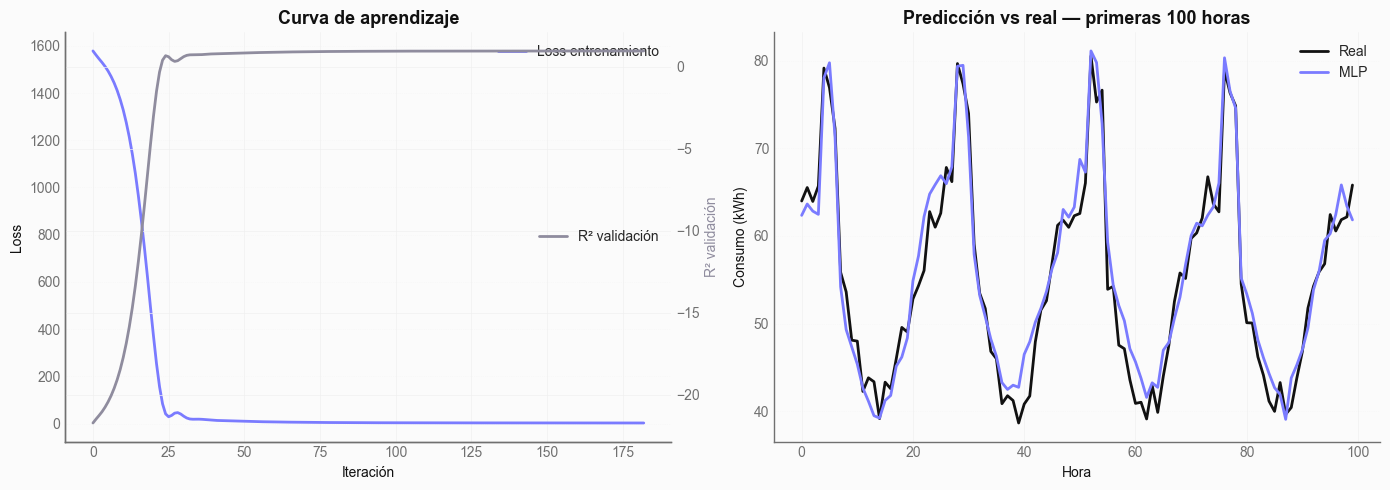

In [12]:
# Curva de aprendizaje y predicciones

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    mlp.loss_curve_,
    color=PURPLE,
    linewidth=2,
    label="Loss entrenamiento"
)

if hasattr(mlp, "validation_scores_"):
    ax2 = axes[0].twinx()

    ax2.plot(
        mlp.validation_scores_,
        color=CONTEXT_LINES[0],
        linewidth=2,
        label="R² validación"
    )

    ax2.set_ylabel("R² validación", color=CONTEXT_LINES[0])
    ax2.legend(loc="center right")

axes[0].set_title("Curva de aprendizaje")
axes[0].set_xlabel("Iteración")
axes[0].set_ylabel("Loss")
axes[0].legend(loc="upper right")
axes[0].grid(axis="y", linestyle=":", alpha=0.5)

axes[1].plot(
    y_test.values[:100],
    color=INK,
    linewidth=2,
    label="Real"
)

axes[1].plot(
    y_pred_mlp[:100],
    color=PURPLE,
    linewidth=2,
    label="MLP"
)

axes[1].set_title("Predicción vs real — primeras 100 horas")
axes[1].set_xlabel("Hora")
axes[1].set_ylabel("Consumo (kWh)")
axes[1].legend()
axes[1].grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()


## 6. Modelos alternativos

Para saber si la complejidad del MLP aporta valor, se utilizan dos referencias:

- **Regresión Lineal:** baseline sencillo e interpretable.
- **Random Forest:** modelo no lineal basado en árboles.


In [13]:
# Regresión Lineal

lr = LinearRegression()

lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict(X_test_sc)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Regresión Lineal:")
print(f"  MAE:  {mae_lr:.2f} kWh")
print(f"  RMSE: {rmse_lr:.2f} kWh")
print(f"  R²:   {r2_lr:.3f}")


Regresión Lineal:
  MAE:  1.76 kWh
  RMSE: 2.21 kWh
  R²:   0.964


In [14]:
# Random Forest Regressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor:")
print(f"  MAE:  {mae_rf:.2f} kWh")
print(f"  RMSE: {rmse_rf:.2f} kWh")
print(f"  R²:   {r2_rf:.3f}")


Random Forest Regressor:
  MAE:  1.57 kWh
  RMSE: 1.89 kWh
  R²:   0.974


## 7. Comparativa de modelos

La comparación se realiza sobre exactamente las mismas observaciones de test.

**Mejor modelo = mayor R² y menores MAE y RMSE.**


In [15]:
# Tabla comparativa

results = pd.DataFrame([
    {
        "Modelo": "MLP (128, 64, 32)",
        "MAE": mae_mlp,
        "RMSE": rmse_mlp,
        "R²": r2_mlp,
    },
    {
        "Modelo": "Regresión Lineal",
        "MAE": mae_lr,
        "RMSE": rmse_lr,
        "R²": r2_lr,
    },
    {
        "Modelo": "Random Forest",
        "MAE": mae_rf,
        "RMSE": rmse_rf,
        "R²": r2_rf,
    }
])

display(
    results.style.format({
        "MAE": "{:.2f}",
        "RMSE": "{:.2f}",
        "R²": "{:.3f}"
    })
)


,Modelo,MAE,RMSE,R²
0,"MLP (128, 64, 32)",1.92,2.43,0.957
1,Regresión Lineal,1.76,2.21,0.964
2,Random Forest,1.57,1.89,0.974


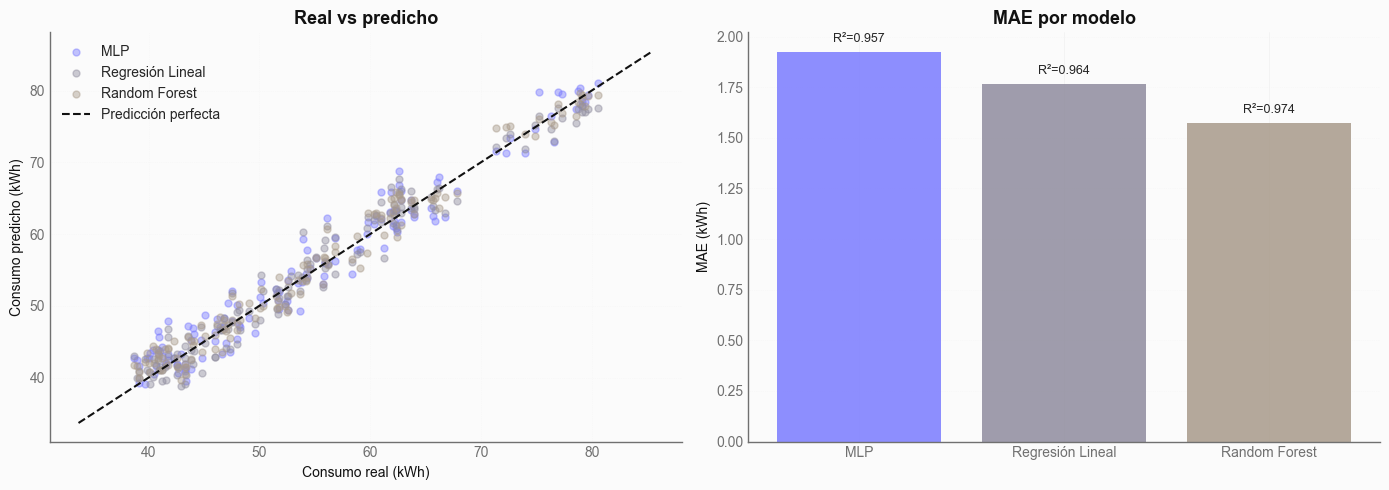

In [16]:
# Comparativa visual

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Real vs predicho

for name, y_pred, color in [
    ("MLP", y_pred_mlp, PURPLE),
    ("Regresión Lineal", y_pred_lr, CONTEXT_LINES[0]),
    ("Random Forest", y_pred_rf, CONTEXT_LINES[1])
]:

    axes[0].scatter(
        y_test,
        y_pred,
        alpha=0.45,
        s=25,
        label=name,
        color=color
    )

lims = [
    y_test.min() - 5,
    y_test.max() + 5
]

axes[0].plot(
    lims,
    lims,
    color=INK,
    linestyle="--",
    linewidth=1.5,
    label="Predicción perfecta"
)

axes[0].set_title("Real vs predicho")
axes[0].set_xlabel("Consumo real (kWh)")
axes[0].set_ylabel("Consumo predicho (kWh)")
axes[0].legend()
axes[0].grid(True, linestyle=":", alpha=0.5)

# MAE

models = ["MLP", "Regresión Lineal", "Random Forest"]
maes = [mae_mlp, mae_lr, mae_rf]
r2s = [r2_mlp, r2_lr, r2_rf]

bars = axes[1].bar(
    models,
    maes,
    color=[PURPLE, CONTEXT_LINES[0], CONTEXT_LINES[1]],
    alpha=0.85
)

axes[1].set_title("MAE por modelo")
axes[1].set_ylabel("MAE (kWh)")
axes[1].grid(axis="y", linestyle=":", alpha=0.5)

for bar, r2 in zip(bars, r2s):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"R²={r2:.3f}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()


## 8. Feature importance — Random Forest

Aunque el MLP es el modelo principal, el Random Forest permite interpretar de forma sencilla qué variables están aportando más información a la predicción.

Esta importancia **no debe interpretarse como si fuera la importancia interna del MLP**.


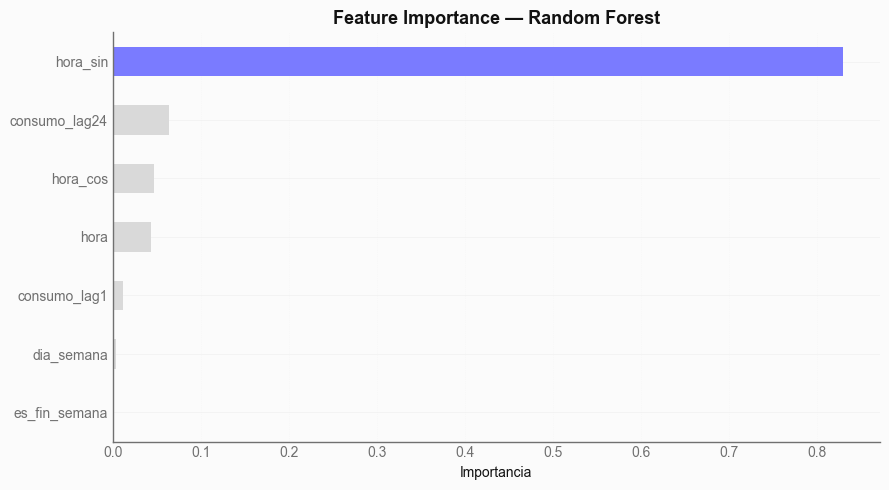

In [17]:
importances = (
    pd.Series(
        rf.feature_importances_,
        index=features
    )
    .sort_values()
)

fig, ax = plt.subplots(figsize=(9, 5))

colors_imp = [PURPLE if v == importances.max() else NEUTRAL_BAR for v in importances.values]

importances.plot(
    kind="barh",
    color=colors_imp,
    ax=ax
)

ax.set_title("Feature Importance — Random Forest")
ax.set_xlabel("Importancia")
ax.grid(axis="x", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()


## 9. Conclusión

### Resultado del experimento

Los tres modelos consiguen un rendimiento elevado, pero **Random Forest es el mejor modelo de los tres en este conjunto de test**.

| Modelo | MAE | RMSE | R² |
|:-------|----:|-----:|----:|
| MLP | 1,92 kWh | 2,43 kWh | 0,957 |
| Regresión Lineal | 1,76 kWh | 2,21 kWh | 0,964 |
| **Random Forest** | **1,57 kWh** | **1,89 kWh** | **0,974** |

### Hallazgo clave

Los **lag features**, especialmente `consumo_lag1` y `consumo_lag24`, concentran una parte importante de la señal predictiva. Esto indica que el consumo reciente y el patrón de las últimas 24 horas son fundamentales para anticipar la siguiente demanda.

### Lectura de negocio

El MLP funciona bien, pero **la red neuronal no justifica por sí sola la complejidad adicional** en este dataset. Random Forest consigue menor error y mayor R², además de ofrecer una lectura más sencilla de la importancia de las variables.


